# Computational Thermofluid Dynamics - Finite Volume Method
==============================================================================================

# Stage 1 – Boundary Derivation
For the **South–West corner node**, write first the general finite volume equation in the same form as Eq. (A.14), including all surface contributions.

Then, impose the **Neumann condition** on the South boundary and the **Dirichlet condition** on the West boundary.  
For the remaining faces, apply Green’s theorem as shown in *Appendix A.2.1*.

Present only the resulting expressions in the same style as Eqs. (A.15)–(A.20) in addition to the boundary conditions, without repeating the detailed integration steps.

Write your solutions in LateX format here


Given below is the generic FVM discritization approximation of Laplacian Operator at South-West Corner Node 
$$
\begin{align}
\nabla^2 T \big|_{SW} &\approx \frac{1}{S_{sw}} \oint_{\partial S_{sw}} \nabla T \cdot \mathbf{n} \, dS \nonumber \\
&\approx \frac{1}{S_{sw}} \Big[
\nabla T \big|_{P} \cdot \mathbf{n} \, \Delta l_{P}^{e}
+ \frac{\partial T}{\partial x} \bigg|_{nne} \Delta y_{e}^{ne}
- \frac{\partial T}{\partial y} \bigg|_{nne} \Delta x_{e}^{ne}
+ \frac{\partial T}{\partial x} \bigg|_{nee} \Delta y_{ne}^{n}
- \frac{\partial T}{\partial y} \bigg|_{nee} \Delta x_{ne}^{n}
+ \nabla T \big|_{P} \cdot \mathbf{n} \, \Delta l_{n}^{P}
\Big]
\end{align}
$$

Applying Green’s theorem to East face derivative:
$$
\begin{align}
\frac{\partial T}{\partial x} \big|_{nne} &\approx \frac{1}{S_{swe}} \oint_{\partial S_{swe}} T \, dy 
\approx \frac{1}{S_{swe}} \big( 
\Delta y_{P}^{E} T \big|_{e} 
+ \Delta y_{E}^{nE} T \big|_{nnE} 
+ \Delta y_{nE}^{n} T \big|_{ne} 
+ \Delta y_{n}^{P} T \big|_{nn} 
\big)  \\
\frac{\partial T}{\partial y} \big|_{nne} &\approx \frac{-1}{S_{swe}} \oint_{\partial S_{swe}} T \, dx 
\approx \frac{-1}{S_{swe}} \big( 
\Delta x_{P}^{E} T \big|_{e} 
+ \Delta x_{E}^{nE} T \big|_{nnE} 
+ \Delta x_{nE}^{n} T \big|_{ne} 
+ \Delta x_{n}^{P} T \big|_{nn} 
\big) 
\end{align}
$$

Applying Green’s theorem to North face derivative:

$$
\begin{align}
\frac{\partial T}{\partial x} \big|_{nee} &\approx \frac{1}{S_{swn}} \oint_{\partial S_{swn}} T \, dy 
\approx \frac{1}{S_{swn}} \big( 
\Delta y_{e}^{Ne} T \big|_{ne} 
+ \Delta y_{Ne}^{N} T \big|_{Nee} 
+ \Delta y_{N}^{P} T \big|_{n} 
+ \Delta y_{P}^{e} T \big|_{ee} 
\big) 
 \\
\frac{\partial T}{\partial y} \big|_{nee} &\approx \frac{-1}{S_{swn}} \oint_{\partial S_{swn}} T \, dx
\approx \frac{1}{S_{swn}} \big( 
\Delta x_{e}^{Ne} T \big|_{ne} 
+ \Delta x_{Ne}^{N} T \big|_{Nee} 
+ \Delta x_{N}^{P} T \big|_{n} 
+ \Delta x_{P}^{e} T \big|_{ee} 
\big) 
\end{align}
$$
Note given below are some important relations:
$$
\begin{align}
T_e=\frac{T_P+T_E}{2}
\\
T_{nnE}=\frac{3T_E+T_{NE}}{4}
\\
T_{ne}=\frac{T_N+T_{NE}+T_P+T_E}{4}
\\
T_{nn}=\frac{3T_P+T_N}{4}
\\
T_{Nee}=\frac{3T_N+T_{NE}}{4}
\\
T_n=\frac{T_N+T_P}{2}
\\
T_{ee}=\frac{3T_P+T_E}{4}
\end{align}
$$
South Face Neumann Boundary Condition:

$$
\nabla T \big|_S \cdot \mathbf{n}_S = -\dot{q} 
$$

West Face Dirichlet Boundary Condition:
$$
T_{n}^{P} = T_{D} 
$$

# Stage 2 – Solver Implementation

In this stage, you will implement a **2D steady-state heat conduction solver** using the Finite Volume Method (FVM) with all boundary condition types.

The **form function** defining the geometry is already provided — do **not** modify it.  
Your task starts from the **mesh generation** using `setupMesh()`.  
First, **visualize the mesh** to verify that the geometry and node layout are correct.

Next, complete the helper class and functions:
- `Coordinate2D` class  
- `calculate_area`, `dx`, `dy`, `dist`, and `index` functions  
Refer to the provided Skriptum for the necessary geometric and differential relations.

In the **main solver class**:
1. Initialize all required parameters similarly to the Finite Difference (FD) exercise.  
2. In the `set_stencil()` method, identify whether each node belongs to the interior, boundary, or corner region, and call the respective `build_*()` function.  
   - `build_inner()` and `build_north()` are already implemented as examples.  
   - You must implement the remaining boundary and corner functions yourself.

Inside the `solve()` method:
- Loop through each node in the computational domain.  
- Call `set_stencil()` for each node to assemble the global coefficient matrix **A** and source vector **B**.  
- After assembly, solve the linear system and reshape the resulting temperature field into 2D form.

Finally, visualize the computed temperature field using the provided plotting routine.  
Note that you are solving only the **upper half** of the geometry.  
Reconstruct the full domain for plotting using `np.flipud()` and `np.vstack()` to mirror the field across the symmetry line.


In [156]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve

## Form function to change the shape of domain
![Domain](domain.png)
see Figure 3.4


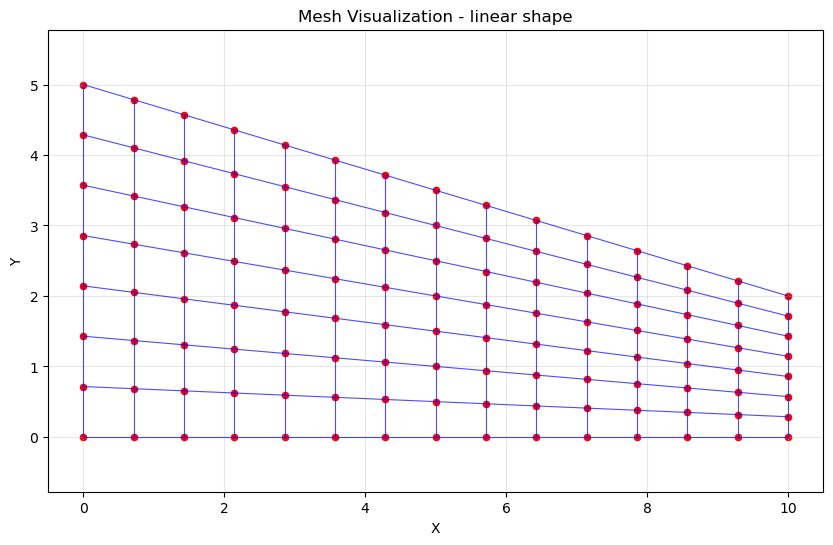

In [157]:
def formfunction(x, shape):
    """
    Defines the shape of north boundary
    takes an array and shape
    returns an array
    """
    h1 = x[-1]           # west boundary height
    h2 = x[-1] / 10 * 4  # east boundary height
    l  = x[-1]           # domain length
    if shape == 'linear':
        m = (h2 - h1) / (2 * l)
        b = h1 / 2
        return m * x + b
    
    elif shape == 'rectangular':
        return l * np.ones((x.size, 1))
        
    elif shape == 'quadratic':
        k = 2 * l**2 / (h1 - h2)
        return (x - l)**2 / k + h2 / 2 
    
    elif shape == 'crazy':
        return h1/2 + (h2/2 - h1/2) * x / l + 0.25*(-h1 + h2/2) * np.sin(np.pi*x/l)**2
    
    else:
        raise ValueError('Unknown shape: %s' % shape)

def setUpMesh(nodes_x, nodes_y, length, formfunction, shape):
    # 1D x coordinates
    X = np.linspace(0, length, nodes_x)

    # Compute half-height profile along X
    y_profile = formfunction(X, shape).flatten() 
    
    # Initialize Y mesh
    Y = np.zeros((nodes_y, nodes_x))
    
    for j in range(nodes_x):
        # Local half height at this x-position
        local_h = y_profile[j]
        
        # Linear distribution from local height to 0 along Y-direction
        Y[:, j] = np.linspace(local_h, 0, nodes_y)
    
    # Repeat X along rows to create 2D mesh
    X = np.array([X[:] for i in range(nodes_y)])
    
    return X, Y
# Parameters for mesh generation
nodes_x = 15
nodes_y = 8
length = 10

# Change this variable to plot different shapes
selected_shape = 'linear'  # Options: 'linear', 'rectangular', 'quadratic', 'crazy'

# Generate and visualize mesh for the selected shape
X, Y = setUpMesh(nodes_x, nodes_y, length, formfunction, selected_shape)

plt.figure(figsize=(10, 6))
plt.plot(X, Y, 'b-', linewidth=0.8, alpha=0.7)
plt.plot(X.T, Y.T, 'b-', linewidth=0.8, alpha=0.7)
plt.scatter(X, Y, c='red', s=20)
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Mesh Visualization - {selected_shape} shape')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

In [158]:
class Coordinate2D():
    def __init__(self, x, y):
        self.x = x
        self.y = y

def calculate_area(ul, bl, br, ur):
    # calculate the area of the cell
    # ul (upper left), bl (bottom left), br (bottom right), ur (upper right) are the coordinates of the four vertices of the cell
    # apply Gaussian trapezoidal formula to calculate the areas

    x = [ul.x, bl.x, br.x, ur.x]
    y = [ul.y, bl.y, br.y, ur.y]
    
    area = 0.5 * abs(
        x[0]*y[1] + x[1]*y[2] + x[2]*y[3] + x[3]*y[0] - y[0]*x[1] - y[1]*x[2] - y[2]*x[3] - y[3]*x[0]
        )
    return area

def dy(a, b):
    # Calculate distance between 'a' and 'b' along the y axis
    return (b.y - a.y)
    
def dx(a, b):
    # Calculate distance between 'a' and 'b' along the x axis
    return (b.x - a.x)
    
def dist(a, b):
    # Calculate the euclidean distance between 'a' and 'b'
    return np.sqrt((b.x - a.x)**2 + (b.y - a.y)**2)

In [159]:
class SteadyHeat2D_FVM():
    def __init__(self, X, Y, boundary=[], TD=[], q=0.0, alpha=0.0, Tinf=0.0):
        # i, j is the index of the cell
        # X, Y is the mesh
        # boundary is the boundary condition: "R", "D", "N"
        # TD is the Dirichlet Temperature
        # q is the heat flux
        # alpha is the heat transfer coefficient
        # Tinf is the temperature of the surrounding

        self.X = X
        self.Y = Y
        self.boundary = boundary
        self.TD = TD
        self.q = q
        self.alpha = alpha
        self.Tinf = Tinf

        # n is the number of points in the first direction
        # m is the number of points in the second direction
        self.m, self.n = X.shape

        total_nodes = self.m * self.n
        self.A = sp.lil_matrix((total_nodes, total_nodes))
        self.B = np.zeros(total_nodes)

    def index(self, i, j):
        # Return the index in the computational vector
       return i * self.n + j
       
    def stable_area(self, *args):
         # Stable area calculation wrapper
         area = calculate_area(*args)
         return area if area > 1e-12 else 1e-12

    def set_stencil(self, i, j):
        # Based on 'i','j' decide if the node is inner or boundary (which boundary?)
        # Check for corner nodes first
        if i == 0 and j == 0:  # North-West corner
            return self.build_NW(i, j)
        elif i == 0 and j == self.n-1:  # North-East corner  
            return self.build_NE(i, j)
        elif i == self.m-1 and j == 0:  # South-West corner
            return self.build_SW(i, j)
        elif i == self.m-1 and j == self.n-1:  # South-East corner
            return self.build_SE(i, j)
        # Check for boundary nodes
        elif i == 0:  # North boundary
            return self.build_north(i, j)
        elif i == self.m-1:  # South boundary
            return self.build_south(i, j)
        elif j == 0:  # West boundary
            return self.build_west(i, j)
        elif j == self.n-1:  # East boundary
            return self.build_east(i, j)
        else:  # Inner node
            return self.build_inner(i, j)

    def build_inner(self, i, j):
        stencil = np.zeros(self.n*self.m)
        b = np.zeros(1)
        # % Nomenclature:
        # %
        # %    NW(i-1,j-1)   Nw -  N(i-1,j) -  Ne     NE(i-1,j+1)
        # %
        # %                 |                 |
        # %
        # %       nW - - - - nw ------ n ------ ne - - - nE
        # %                 |                 |
        # %       |         |        |        |       |
        # %                 |                 |
        # %   W(i, j-1) - - w - - P (i,j) - - e - -  E (i,j+1)
        # %                 |                 |
        # %       |         |        |        |       |
        # %                 |                 |
        # %      sW - - - - sw ------ s ------ se - - - sE
        # %
        # %                 |                 |
        # %
        # %   SW(i+1,j-1)   Sw  -  S(i+1,j)  - Se      SE(i+1,j+1)
        # %
        # % Indexing of stencil: 

        # %    D_4 - D_1 - D2
        # %     |     |     | 
        # %    D_3 - D_0 - D3
        # %     |     |     | 
        # %    D_2 -  D1 - D4

        # principle node coordinate
        P = Coordinate2D(self.X[i, j], self.Y[i, j])
        N = Coordinate2D(self.X[i-1, j], self.Y[i-1, j])
        S = Coordinate2D(self.X[i+1, j], self.Y[i+1, j])
        W = Coordinate2D(self.X[i, j-1], self.Y[i, j-1])
        E = Coordinate2D(self.X[i, j+1], self.Y[i, j+1])
        NW = Coordinate2D(self.X[i-1, j-1], self.Y[i-1, j-1])
        NE = Coordinate2D(self.X[i-1, j+1], self.Y[i-1, j+1])
        SW = Coordinate2D(self.X[i+1, j-1], self.Y[i+1, j-1])
        SE = Coordinate2D(self.X[i+1, j+1], self.Y[i+1, j+1])

        # auxiliary node coordinate
        Nw = Coordinate2D((N.x + NW.x)/2, (N.y + NW.y)/2)
        Ne = Coordinate2D((N.x + NE.x)/2, (N.y + NE.y)/2)
        Sw = Coordinate2D((S.x + SW.x)/2, (S.y + SW.y)/2)
        Se = Coordinate2D((S.x + SE.x)/2, (S.y + SE.y)/2)
        nW = Coordinate2D((W.x + NW.x)/2, (W.y + NW.y)/2)
        nE = Coordinate2D((E.x + NE.x)/2, (E.y + NE.y)/2)
        sW = Coordinate2D((W.x + SW.x)/2, (W.y + SW.y)/2)
        sE = Coordinate2D((E.x + SE.x)/2, (E.y + SE.y)/2)

        n = Coordinate2D((N.x + P.x)/2, (N.y + P.y)/2)
        s = Coordinate2D((S.x + P.x)/2, (S.y + P.y)/2)
        w = Coordinate2D((W.x + P.x)/2, (W.y + P.y)/2)
        e = Coordinate2D((E.x + P.x)/2, (E.y + P.y)/2)

        se = Coordinate2D((Se.x + e.x)/2, (Se.y + e.y)/2)
        sw = Coordinate2D((Sw.x + w.x)/2, (Sw.y + w.y)/2)
        ne = Coordinate2D((Ne.x + e.x)/2, (Ne.y + e.y)/2)
        nw = Coordinate2D((Nw.x + w.x)/2, (Nw.y + w.y)/2)
        
        # calculate the area of the cell
        S_P = calculate_area(ne, se, sw, nw)
        S_n = calculate_area(Ne, e, w, Nw)
        S_s = calculate_area(e, Se, Sw, w)
        S_w = calculate_area(n, s, sW, nW)
        S_e = calculate_area(nE, sE, s, n)

        D3 = ((dx(se, ne) * (dx(nE, n)/4 + dx(s, sE)/4 + dx(sE, nE))) / S_e + 
             (dy(se, ne) * (dy(nE, n)/4 + dy(s, sE)/4 + dy(sE, nE))) / S_e + 
             (dx(e, Ne) * dx(ne, nw)) / (4*S_n) + (dx(Se,e) * dx(sw,se)) / (4*S_s) + 
             (dy(e, Ne) * dy(ne, nw)) / (4*S_n) + (dy(Se,e) * dy(sw,se)) / (4*S_s)) / S_P
        D_3 = ((dx(nw, sw) * (dx(n, nW) / 4 + dx(sW, s) / 4 + dx(nW, sW))) / S_w +
              (dy(nw, sw) * (dy(n, nW) / 4 + dy(sW, s) / 4 + dy(nW, sW))) / S_w +
              (dx(Nw, w) * dx(ne, nw)) / (4 * S_n) +
              (dx(w, Sw) * dx(sw, se)) / (4 * S_s) +
              (dy(Nw, w) * dy(ne, nw)) / (4 * S_n) +
              (dy(w, Sw) * dy(sw, se)) / (4 * S_s)) / S_P
        D1 = ((dx(sw, se) * (dx(Se, e) / 4 + dx(w, Sw) / 4 + dx(Sw, Se))) / S_s +
            (dy(sw, se) * (dy(Se, e) / 4 + dy(w, Sw) / 4 + dy(Sw, Se))) / S_s +
            (dx(s, sE) * dx(se, ne)) / (4 * S_e) +
            (dx(sW, s) * dx(nw, sw)) / (4 * S_w) +
            (dy(s, sE) * dy(se, ne)) / (4 * S_e) +
            (dy(sW, s) * dy(nw, sw)) / (4 * S_w)) / S_P
        # North
        D_1 = ((dx(ne, nw) * (dx(e, Ne) / 4 + dx(Nw, w) / 4 + dx(Ne, Nw))) / S_n +
            (dy(ne, nw) * (dy(e, Ne) / 4 + dy(Nw, w) / 4 + dy(Ne, Nw))) / S_n +
            (dx(nE, n) * dx(se, ne)) / (4 * S_e) +
            (dx(n, nW) * dx(nw, sw)) / (4 * S_w) +
            (dy(nE, n) * dy(se, ne)) / (4 * S_e) +
            (dy(n, nW) * dy(nw, sw)) / (4 * S_w)) / S_P

        # NW
        D_4 = ((dx(Nw, w) * dx(ne, nw)) / (4 * S_n) +
            (dx(n, nW) * dx(nw, sw)) / (4 * S_w) +
            (dy(Nw, w) * dy(ne, nw)) / (4 * S_n) +
            (dy(n, nW) * dy(nw, sw)) / (4 * S_w)) / S_P

        # NE
        D2 = ((dx(nE, n) * dx(se, ne)) / (4 * S_e) +
            (dx(e, Ne) * dx(ne, nw)) / (4 * S_n) +
            (dy(nE, n) * dy(se, ne)) / (4 * S_e) +
            (dy(e, Ne) * dy(ne, nw)) / (4 * S_n)) / S_P

        # SW
        D_2 = ((dx(w, Sw) * dx(sw, se)) / (4 * S_s) +
            (dx(sW, s) * dx(nw, sw)) / (4 * S_w) +
            (dy(w, Sw) * dy(sw, se)) / (4 * S_s) +
            (dy(sW, s) * dy(nw, sw)) / (4 * S_w)) / S_P

        # SE
        D4 = ((dx(s, sE) * dx(se, ne)) / (4 * S_e) +
            (dx(Se, e) * dx(sw, se)) / (4 * S_s) +
            (dy(s, sE) * dy(se, ne)) / (4 * S_e) +
            (dy(Se, e) * dy(sw, se)) / (4 * S_s)) / S_P

        # Center (P)
        D0 = ((dx(se, ne) * (dx(n, s) + dx(nE, n) / 4 + dx(s, sE) / 4)) / S_e +
            (dx(ne, nw) * (dx(w, e) + dx(e, Ne) / 4 + dx(Nw, w) / 4)) / S_n +
            (dx(sw, se) * (dx(e, w) + dx(Se, e) / 4 + dx(w, Sw) / 4)) / S_s +
            (dx(nw, sw) * (dx(s, n) + dx(n, nW) / 4 + dx(sW, s) / 4)) / S_w +
            (dy(se, ne) * (dy(n, s) + dy(nE, n) / 4 + dy(s, sE) / 4)) / S_e +
            (dy(ne, nw) * (dy(w, e) + dy(e, Ne) / 4 + dy(Nw, w) / 4)) / S_n +
            (dy(sw, se) * (dy(e, w) + dy(Se, e) / 4 + dy(w, Sw) / 4)) / S_s +
            (dy(nw, sw) * (dy(s, n) + dy(n, nW) / 4 + dy(sW, s) / 4)) / S_w) / S_P
        
        stencil[self.index(i, j)] = D0
        stencil[self.index(i-1, j)] = D_1
        stencil[self.index(i+1, j)] = D1
        stencil[self.index(i, j-1)] = D_3
        stencil[self.index(i, j+1)] = D3
        stencil[self.index(i-1, j-1)] = D_4
        stencil[self.index(i-1, j+1)] = D2
        stencil[self.index(i+1, j-1)] = D_2
        stencil[self.index(i+1, j+1)] = D4
        
        return stencil,b
        
    
    def build_north(self, i, j):
        stencil = np.zeros(self.n*self.m)
        b = np.zeros(1)
        if self.boundary[0] == 'D':
            stencil[self.index(i, j)] = 1.0
            b = self.TD[0]
        else: 
            # principle node coordinate
            P = Coordinate2D(self.X[i, j], self.Y[i, j])
            S = Coordinate2D(self.X[i+1, j], self.Y[i+1, j])
            W = Coordinate2D(self.X[i, j-1], self.Y[i, j-1])
            E = Coordinate2D(self.X[i, j+1], self.Y[i, j+1])
            SW = Coordinate2D(self.X[i+1, j-1], self.Y[i+1, j-1])
            SE = Coordinate2D(self.X[i+1, j+1], self.Y[i+1, j+1])

            # auxiliary node coordinate
            Sw = Coordinate2D((S.x + SW.x)/2, (S.y + SW.y)/2)
            Se = Coordinate2D((S.x + SE.x)/2, (S.y + SE.y)/2)
            sW = Coordinate2D((W.x + SW.x)/2, (W.y + SW.y)/2)
            sE = Coordinate2D((E.x + SE.x)/2, (E.y + SE.y)/2)

            s = Coordinate2D((S.x + P.x)/2, (S.y + P.y)/2)
            w = Coordinate2D((W.x + P.x)/2, (W.y + P.y)/2)
            e = Coordinate2D((E.x + P.x)/2, (E.y + P.y)/2)

            se = Coordinate2D((Se.x + e.x)/2, (Se.y + e.y)/2)
            sw = Coordinate2D((Sw.x + w.x)/2, (Sw.y + w.y)/2)

            # calculate the area of the cell
            S_ss = calculate_area(e, se, sw, w)
            S_s = calculate_area(e, Se, Sw, w)
            S_ssw = calculate_area(P, s, sW, W)
            S_sse = calculate_area(E, sE, s, P)

            # East
            D3 = (dy(sw, se) * (dy(Se, e) / 4) / S_s + dx(sw, se) * (dx(Se, e) / 4) / S_s +
                dy(se, e) * (dy(s, sE) / 4 + 3 * dy(sE, E) / 4 + dy(E, P) / 2) / S_sse +
                dx(se, e) * (dx(s, sE) / 4 + 3 * dx(sE, E) / 4 + dx(E, P) / 2) / S_sse) / S_ss

            # West
            D_3 = (dy(w, sw) * (3 * dy(W, sW) / 4 + dy(sW, s) / 4 + dy(P, W) / 2) / S_ssw +
                dx(w, sw) * (3 * dx(W, sW) / 4 + dx(sW, s) / 4 + dx(P, W) / 2) / S_ssw +
                dy(sw, se) * (dy(w, Sw) / 4) / S_s + dx(sw, se) * (dx(w, Sw) / 4) / S_s) / S_ss

            # South
            D1 = (dy(w, sw) * (dy(sW, s) / 4 + dy(s, P) / 4) / S_ssw +
                dx(w, sw) * (dx(sW, s) / 4 + dx(s, P) / 4) / S_ssw +
                dy(sw, se) * (dy(w, Sw) / 4 + dy(Sw, Se) + dy(Se, e) / 4) / S_s +
                dx(sw, se) * (dx(w, Sw) / 4 + dx(Sw, Se) + dx(Se, e) / 4) / S_s +
                dy(se, e) * (dy(P, s) / 4 + dy(s, sE) / 4) / S_sse +
                dx(se, e) * (dx(P, s) / 4 + dx(s, sE) / 4) / S_sse) / S_ss

            # SW
            D_2 = (dy(w, sw) * (dy(W, sW) / 4 + dy(sW, s) / 4) / S_ssw +
                dx(w, sw) * (dx(W, sW) / 4 + dx(sW, s) / 4) / S_ssw +
                dy(sw, se) * (dy(w, Sw) / 4) / S_s + dx(sw, se) * (dx(w, Sw) / 4) / S_s) / S_ss

            # SE
            D4 = (dy(sw, se) * (dy(Se, e) / 4) / S_s + dx(sw, se) * (dx(Se, e) / 4) / S_s +
                dy(se, e) * (dy(s, sE) / 4 + dy(sE, E) / 4) / S_sse +
                dx(se, e) * (dx(s, sE) / 4 + dx(sE, E) / 4) / S_sse) / S_ss
            
            coefficient = 0.0
            if self.boundary[0] == 'N':
                coefficient = 0.0
                b = self.q * dist(e, w) / S_ss
            elif self.boundary[0] == 'R':
                coefficient = - self.alpha
                b = - self.alpha * self.Tinf * dist(e, w) / S_ss
            else:
                raise ValueError('Unknown boundary type: %s' % boundary[0])
            
            D0 = (coefficient * dist(e, w) +
                dy(w, sw) * (dy(sW, s) / 4 + 3 * dy(s, P) / 4 + dy(P, W) / 2) / S_ssw +
                dx(w, sw) * (dx(sW, s) / 4 + 3 * dx(s, P) / 4 + dx(P, W) / 2) / S_ssw +
                dy(sw, se) * (dy(w, Sw) / 4 + dy(Se, e) / 4 + dy(e, w)) / S_s +
                dx(sw, se) * (dx(w, Sw) / 4 + dx(Se, e) / 4 + dx(e, w)) / S_s +
                dy(se, e) * (3 * dy(P, s) / 4 + dy(s, sE) / 4 + dy(E, P) / 2) / S_sse +
                dx(se, e) * (3 * dx(P, s) / 4 + dx(s, sE) / 4 + dx(E, P) / 2) / S_sse) / S_ss
            
            stencil[self.index(i, j)] = D0
            stencil[self.index(i+1, j)] = D1
            stencil[self.index(i, j-1)] = D_3
            stencil[self.index(i, j+1)] = D3
            stencil[self.index(i+1, j-1)] = D_2
            stencil[self.index(i+1, j+1)] = D4

        return stencil,b
    
    def build_south(self, i, j):
        """Build stencil for south boundary"""
        stencil = np.zeros(self.m * self.n)
        b = np.zeros(1)  

        if self.boundary[1] == 'D':
            stencil[self.index(i, j)] = 1.0
            b[0] = self.TD[1]  
            return stencil, b[0] 

        P  = Coordinate2D(self.X[i, j], self.Y[i, j])
        N  = Coordinate2D(self.X[i-1, j], self.Y[i-1, j])
        W  = Coordinate2D(self.X[i, j-1], self.Y[i, j-1])
        E  = Coordinate2D(self.X[i, j+1], self.Y[i, j+1])
        NW = Coordinate2D(self.X[i-1, j-1], self.Y[i-1, j-1])
        NE = Coordinate2D(self.X[i-1, j+1], self.Y[i-1, j+1])

        Nw = Coordinate2D((N.x + NW.x)/2, (N.y + NW.y)/2)
        Ne = Coordinate2D((N.x + NE.x)/2, (N.y + NE.y)/2)
        nW = Coordinate2D((W.x + NW.x)/2, (W.y + NW.y)/2)
        nE = Coordinate2D((E.x + NE.x)/2, (E.y + NE.y)/2)

        n  = Coordinate2D((N.x + P.x)/2, (N.y + P.y)/2)
        w  = Coordinate2D((W.x + P.x)/2, (W.y + P.y)/2)
        e  = Coordinate2D((E.x + P.x)/2, (E.y + P.y)/2)

        ne = Coordinate2D((Ne.x + e.x)/2, (Ne.y + e.y)/2)
        nw = Coordinate2D((Nw.x + w.x)/2, (Nw.y + w.y)/2)

        S_nn  = self.stable_area(e, ne, nw, w)
        S_n   = self.stable_area(e, Ne, Nw, w)
        S_nnw = self.stable_area(P, n, nW, W)
        S_nne = self.stable_area(E, nE, n, P)

        D3 = (dy(nw, ne) * dy(Ne, e) / 4 / S_n + dx(nw, ne) * dx(Ne, e) / 4 / S_n +
            dy(ne, e) * (dy(n, nE)/4 + 3*dy(nE, E)/4 + dy(E, P)/2) / S_nne +
            dx(ne, e) * (dx(n, nE)/4 + 3*dx(nE, E)/4 + dx(E, P)/2) / S_nne) / S_nn

        D_3 = (dy(w, nw) * (3*dy(W, nW)/4 + dy(nW, n)/4 + dy(P, W)/2) / S_nnw +
            dx(w, nw) * (3*dx(W, nW)/4 + dx(nW, n)/4 + dx(P, W)/2) / S_nnw +
            dy(nw, ne) * dy(w, Nw)/4 / S_n + dx(nw, ne) * dx(w, Nw)/4 / S_n) / S_nn

        D_1 = (dy(w, nw) * (dy(nW, n)/4 + dy(n, P)/4) / S_nnw +
            dx(w, nw) * (dx(nW, n)/4 + dx(n, P)/4) / S_nnw +
            dy(nw, ne) * (dy(w, Nw)/4 + dy(Nw, Ne) + dy(Ne, e)/4) / S_n +
            dx(nw, ne) * (dx(w, Nw)/4 + dx(Nw, Ne) + dx(Ne, e)/4) / S_n +
            dy(ne, e) * (dy(P, n)/4 + dy(n, nE)/4) / S_nne +
            dx(ne, e) * (dx(P, n)/4 + dx(n, nE)/4) / S_nne) / S_nn

        D4 = (dy(w, nw) * (dy(W, nW)/4 + dy(nW, n)/4) / S_nnw +
            dx(w, nw) * (dx(W, nW)/4 + dx(nW, n)/4) / S_nnw +
            dy(nw, ne) * dy(w, Nw)/4 / S_n + dx(nw, ne) * dx(w, Nw)/4 / S_n) / S_nn

        D2 = (dy(nw, ne) * dy(Ne, e)/4 / S_n + dx(nw, ne) * dx(Ne, e)/4 / S_n +
            dy(ne, e) * (dy(n, nE)/4 + dy(nE, E)/4) / S_nne +
            dx(ne, e) * (dx(n, nE)/4 + dx(nE, E)/4) / S_nne) / S_nn

        if self.boundary[1] == 'N':
            coefficient = 0.0
            b[0] = self.q * dist(e, w) / S_nn  
        elif self.boundary[1] == 'R':
            coefficient = -self.alpha
            b[0] = -self.alpha * self.Tinf * dist(e, w) / S_nn 
        else:
            raise ValueError(f'Unknown boundary type: {self.boundary[1]}')

        D0 = (coefficient * dist(e, w) +
            dy(w, nw) * (dy(nW, n)/4 + 3*dy(n, P)/4 + dy(P, W)/2) / S_nnw +
            dx(w, nw) * (dx(nW, n)/4 + 3*dx(n, P)/4 + dx(P, W)/2) / S_nnw +
            dy(nw, ne) * (dy(w, Nw)/4 + dy(Ne, e)/4 + dy(e, w)) / S_n +
            dx(nw, ne) * (dx(w, Nw)/4 + dx(Ne, e)/4 + dx(e, w)) / S_n +
            dy(ne, e) * (3*dy(P, n)/4 + dy(n, nE)/4 + dy(E, P)/2) / S_nne +
            dx(ne, e) * (3*dx(P, n)/4 + dx(n, nE)/4 + dx(E, P)/2) / S_nne) / S_nn

        stencil[self.index(i, j)]     = D0
        stencil[self.index(i-1, j)]   = D_1
        stencil[self.index(i, j-1)]   = D_3
        stencil[self.index(i, j+1)]   = D3
        stencil[self.index(i-1, j-1)] = D4
        stencil[self.index(i-1, j+1)] = D2

        return stencil, b[0]
    
    def build_west(self, i, j):
        """Build stencil for west boundary"""
        stencil = np.zeros(self.m * self.n)
        b = np.zeros(1)  

        if self.boundary[2] == 'D':
            stencil[self.index(i, j)] = 1.0
            b[0] = self.TD[2]  
            return stencil, b[0]  

        P = Coordinate2D(self.X[i, j], self.Y[i, j])
        S = Coordinate2D(self.X[i+1, j], self.Y[i+1, j])
        N = Coordinate2D(self.X[i-1, j], self.Y[i-1, j])
        E = Coordinate2D(self.X[i, j+1], self.Y[i, j+1])
        SE = Coordinate2D(self.X[i+1, j+1], self.Y[i+1, j+1])
        NE = Coordinate2D(self.X[i-1, j+1], self.Y[i-1, j+1])

        Se = Coordinate2D((S.x + SE.x)/2, (S.y + SE.y)/2)
        Ne = Coordinate2D((N.x + NE.x)/2, (N.y + NE.y)/2)
        sE = Coordinate2D((E.x + SE.x)/2, (E.y + SE.y)/2)
        nE = Coordinate2D((E.x + NE.x)/2, (E.y + NE.y)/2)

        s = Coordinate2D((S.x + P.x)/2, (S.y + P.y)/2)
        n = Coordinate2D((N.x + P.x)/2, (N.y + P.y)/2)
        e = Coordinate2D((E.x + P.x)/2, (E.y + P.y)/2)

        ne = Coordinate2D((Ne.x + e.x)/2, (Ne.y + e.y)/2)
        se = Coordinate2D((Se.x + e.x)/2, (Se.y + e.y)/2)

        S_ww = self.stable_area(s, n, ne, se)
        S_w = self.stable_area(s, n, nE, sE)
        S_wws = self.stable_area(S, P, e, Se)
        S_wwn = self.stable_area(P, N, Ne, e)

        D_1 = -(dy(se, ne) * (dy(nE, n) / 4) / S_w + dx(se, ne) * (dx(nE, n) / 4) / S_w +
                dy(ne, n) * (dy(e, Ne) / 4 + 3 * dy(Ne, N) / 4 + dy(N, P) / 2) / S_wwn +
                dx(ne, n) * (dx(e, Ne) / 4 + 3 * dx(Ne, N) / 4 + dx(N, P) / 2) / S_wwn) / S_ww

        D1 = -(dy(se, ne) * (dy(s, sE) / 4) / S_w + dx(se, ne) * (dx(s, sE) / 4) / S_w +
                dy(se, s) * (dy(sE, S) / 4 + 3 * dy(Se, S) / 4 + dy(S, P) / 2) / S_wws +
                dx(se, s) * (dx(sE, S) / 4 + 3 * dx(Se, S) / 4 + dx(S, P) / 2) / S_wws) / S_ww

        D3 = -(dy(s, se) * (dy(Se, e) / 4 + dy(e, P) / 4) / S_wws +
                dx(s, se) * (dx(Se, e) / 4 + dx(e, P) / 4) / S_wws +
                dy(se, ne) * (dy(s, sE) / 4 + dy(sE, nE) + dy(nE, n) / 4) / S_w +
                dx(se, ne) * (dx(s, sE) / 4 + dx(sE, nE) + dx(nE, n) / 4) / S_w +
                dy(ne, n) * (dy(P, e) / 4 + dy(e, Ne) / 4) / S_wwn +
                dx(ne, n) * (dx(P, e) / 4 + dx(e, Ne) / 4) / S_wwn) / S_ww

        D2 = -(dy(ne, n) * (dy(e, Ne) / 4 + dy(Ne, N) / 4) / S_wwn +
                dx(ne, n) * (dx(e, Ne) / 4 + dx(Ne, N) / 4) / S_wwn +
                dy(se, ne) * (dy(nE, n) / 4) / S_w + dx(se, ne) * (dx(nE, n) / 4) / S_w) / S_ww

        D4 = -(dy(se, ne) * (dy(s, sE) / 4) / S_w + dx(se, ne) * (dx(Se, s) / 4) / S_w +
                dy(s, se) * (dy(Se, e) / 4 + dy(Se, S) / 4) / S_wws +
                dx(s, se) * (dx(Se, e) / 4 + dx(Se, S) / 4) / S_wws) / S_ww
        
        if self.boundary[2] == 'N':
            coefficient = 0.0
            b[0] = self.q * dist(n, s) / S_ww  
        elif self.boundary[2] == 'R':
            coefficient = -self.alpha
            b[0] = -self.alpha * self.Tinf * dist(n, s) / S_ww  
        else:
            raise ValueError(f'Unknown boundary type: {self.boundary[2]}')
        
        D0 = (coefficient * dist(ne, se) +
                dy(s, se) * (dy(Se, e) / 4 + 3 * dy(e, P) / 4 + dy(P, S) / 2) / S_wws +
                dx(s, se) * (dx(Se, e) / 4 + 3 * dx(e, P) / 4 + dx(P, S) / 2) / S_wws +
                dy(se, ne) * (dy(s, sE) / 4 + dy(nE, n) / 4 + dy(n, s)) / S_w +
                dx(se, ne) * (dx(s, sE) / 4 + dx(nE, n) / 4 + dx(n, s)) / S_w +
                dy(ne, n) * (3 * dy(P, e) / 4 + dy(e, Ne) / 4 + dy(N, P) / 2) / S_wwn +
                dx(ne, n) * (3 * dx(P, e) / 4 + dx(e, Ne) / 4 + dx(N, P) / 2) / S_wwn) / S_ww
        
        stencil[self.index(i, j)] = D0
        stencil[self.index(i-1, j)] = D_1
        stencil[self.index(i+1, j)] = D1
        stencil[self.index(i, j+1)] = D3
        stencil[self.index(i-1, j+1)] = D2
        stencil[self.index(i+1, j+1)] = D4

        return stencil, b[0]  
    
    def build_east(self, i, j):
        """Build stencil for east boundary"""
        stencil = np.zeros(self.m * self.n)
        b = np.zeros(1)  
        
        if self.boundary[3] == 'D':
            stencil[self.index(i, j)] = 1.0
            b[0] = self.TD[3]  
            return stencil, b[0]  

        P = Coordinate2D(self.X[i, j], self.Y[i, j])
        S = Coordinate2D(self.X[i+1, j], self.Y[i+1, j])
        W = Coordinate2D(self.X[i, j-1], self.Y[i, j-1])
        N = Coordinate2D(self.X[i-1, j], self.Y[i-1, j])
        SW = Coordinate2D(self.X[i+1, j-1], self.Y[i+1, j-1])
        NW = Coordinate2D(self.X[i-1, j-1], self.Y[i-1, j-1])

        Sw = Coordinate2D((S.x + SW.x)/2, (S.y + SW.y)/2)
        Nw = Coordinate2D((N.x + NW.x)/2, (N.y + NW.y)/2)
        sW = Coordinate2D((W.x + SW.x)/2, (W.y + SW.y)/2)
        nW = Coordinate2D((W.x + NW.x)/2, (W.y + NW.y)/2)

        s = Coordinate2D((S.x + P.x)/2, (S.y + P.y)/2)
        w = Coordinate2D((W.x + P.x)/2, (W.y + P.y)/2)
        n = Coordinate2D((N.x + P.x)/2, (N.y + P.y)/2)

        nw = Coordinate2D((nW.x + n.x)/2, (nW.y + n.y)/2)
        sw = Coordinate2D((sW.x + s.x)/2, (sW.y + s.y)/2)

        S_ee = self.stable_area(s, sw, nw, n)
        S_e = self.stable_area(n, s, sW, nW)
        S_ees = self.stable_area(P, S, Sw, w)
        S_een = self.stable_area(N, P, w, Nw)

        D_1 = (dy(nw, sw) * (dy(n, nW) / 4) / S_e + dx(nw, sw) * (dx(n, nW) / 4) / S_e +
                dy(n, nw) * (dy(Nw, w) / 4 + 3 * dy(N, Nw) / 4 + dy(P, N) / 2) / S_een +
                dx(n, nw) * (dx(Nw, w) / 4 + 3 * dx(N, Nw) / 4 + dx(P, N) / 2) / S_een) / S_ee
            
        D1 = (dy(nw, sw) * (dy(sW, s) / 4) / S_e + dx(nw, sw) * (dx(sW, s) / 4) / S_e +
                dy(sw, s) * (dy(w, Sw) / 4 + 3 * dy(Sw, S) / 4 + dy(S, P) / 2) / S_ees +
                dx(sw, s) * (dx(w, Sw) / 4 + 3 * dx(Sw, S) / 4 + dx(S, P) / 2) / S_ees) / S_ee

        D_3 = (dy(sw, s) * (dy(w, Sw) / 4 + dy(P, w) / 4) / S_ees +
                dx(sw, s) * (dx(w, Sw) / 4 + dx(P, w) / 4) / S_ees +
                dy(nw, sw) * (dy(sW, s) / 4 + dy(nW, sW) + dy(n, nW) / 4) / S_e +
                dx(nw, sw) * (dx(sW, s) / 4 + dx(nW, sW) + dx(n, nW) / 4) / S_e +
                dy(n, nw) * (dy(w, P) / 4 + dy(Nw, w) / 4) / S_een +
                dx(n, nw) * (dx(w, P) / 4 + dx(Nw, w) / 4) / S_een) / S_ee

        D_4 = (dy(n, nw) * (dy(N, Nw) / 4 + dy(Nw, w) / 4) / S_een +
                dx(n, nw) * (dx(N, Nw) / 4 + dx(Nw, w) / 4) / S_een +
                dy(nw, sw) * (dy(n, nW) / 4) / S_e + dx(nw, sw) * (dx(n, nW) / 4) / S_e) / S_ee

        D_2 = (dy(nw, sw) * (dy(sW, s) / 4) / S_e + dx(nw, sw) * (dx(sW, s) / 4) / S_e +
                dy(sw, s) * (dy(Sw, S) / 4 + dy(w, Sw) / 4) / S_ees +
                dx(sw, s) * (dx(Sw, S) / 4 + dx(w, Sw) / 4) / S_ees) / S_ee
        
        if self.boundary[3] == 'N':
            coefficient = 0.0
            b[0] = self.q * dist(n, s) / S_ee  
        elif self.boundary[3] == 'R':
            coefficient = -self.alpha
            b[0] = -self.alpha * self.Tinf * dist(n, s) / S_ee  
        else:
            raise ValueError(f'Unknown boundary type: {self.boundary[3]}')
        
        D0 = (coefficient * dist(nw, sw) +
                dy(sw, s) * (dy(w, Sw) / 4 + 3 * dy(P, w) / 4 + dy(S, P) / 2) / S_ees +
                dx(sw, s) * (dx(w, Sw) / 4 + 3 * dx(P, w) / 4 + dx(S, P) / 2) / S_ees +
                dy(nw, sw) * (dy(sW, s) / 4 + dy(n, nW) / 4 + dy(s, n)) / S_e +
                dx(nw, sw) * (dx(sW, s) / 4 + dx(n, nW) / 4 + dx(s, n)) / S_e +
                dy(n, nw) * (3 * dy(w, P) / 4 + dy(Nw, w) / 4 + dy(P, N) / 2) / S_een +
                dx(n, nw) * (3 * dx(w, P) / 4 + dx(Nw, w) / 4 + dx(P, N) / 2) / S_een) / S_ee

        stencil[self.index(i, j)] = D0
        stencil[self.index(i-1, j)] = D_1
        stencil[self.index(i+1, j)] = D1
        stencil[self.index(i, j-1)] = D_3
        stencil[self.index(i-1, j-1)] = D_4
        stencil[self.index(i+1, j-1)] = D_2

        return stencil, b[0] 
    
    def build_NW(self, i, j):
        """Build stencil for North-West corner"""
        stencil = np.zeros(self.m * self.n)
        b = np.zeros(1)  

        if self.boundary[0] == 'D':
            stencil[self.index(i, j)] = 1.0
            b[0] = self.TD[0]  
            return stencil, b[0] 
        
        if self.boundary[2] == 'D':
            stencil[self.index(i, j)] = 1.0
            b[0] = self.TD[2]  
            return stencil, b[0] 

        P  = Coordinate2D(self.X[i, j], self.Y[i, j])
        S  = Coordinate2D(self.X[i+1, j], self.Y[i+1, j])
        E  = Coordinate2D(self.X[i, j+1], self.Y[i, j+1])
        SE = Coordinate2D(self.X[i+1, j+1], self.Y[i+1, j+1])

        s   = Coordinate2D((S.x + P.x)/2, (S.y + P.y)/2)
        e   = Coordinate2D((E.x + P.x)/2, (E.y + P.y)/2)
        Se  = Coordinate2D((S.x + SE.x)/2, (S.y + SE.y)/2)
        sE  = Coordinate2D((E.x + SE.x)/2, (E.y + SE.y)/2)
        se  = Coordinate2D((Se.x + e.x)/2, (Se.y + e.y)/2)

        S_nw  = self.stable_area(P, s, se, e)       
        S_nws = self.stable_area(P, S, Se, e)
        S_nwe = self.stable_area(P, s, sE, E)

        coeff_N = coeff_W = 0.0
        b[0] = 0.0  

        if self.boundary[0] == 'N':
            b[0] += self.q * dist(e, P) / S_nw  
        elif self.boundary[0] == 'R':
            coeff_N = -self.alpha
            b[0] += -self.alpha * self.Tinf * dist(e, P) / S_nw  

        if self.boundary[2] == 'N':
            b[0] += self.q * dist(P, s) / S_nw 
        elif self.boundary[2] == 'R':
            coeff_W = -self.alpha
            b[0] += -self.alpha * self.Tinf * dist(P, s) / S_nw 

        D0 = (
            coeff_N * dist(e, P) +
            coeff_W * dist(s, P) +
            dy(s, se) * (dy(Se, e) / 4 + 3 * dy(e, P) / 4 + dy(P, S) / 2) / S_nws +
            dx(s, se) * (dx(Se, e) / 4 + 3 * dx(e, P) / 4 + dx(P, S) / 2) / S_nws +
            dy(se, e) * (3 * dy(s, P)/4 + dy(sE,s)/4 + dy(P, E)/2) / S_nwe +
            dx(se, e) * (3 * dx(s, P)/4 + dx(sE,s)/4 + dx(P, E)/2) / S_nwe
        ) / S_nw

        D1 = (
            dy(s, se) * (dy(e, Se) / 4 + 3 * dy(Se, S) / 4 + dy(S, P) / 2) / S_nws +
            dx(s, se) * (dx(e, Se) / 4 + 3 * dx(Se, S) / 4 + dx(S, P) / 2) / S_nws +
            dy(se, e) * (dy(s, sE)/4 + dy(sE, E)/4) / S_nwe +
            dx(se, e) * (dx(s, sE)/4 + dx(sE, E)/4) / S_nwe
        ) / S_nw

        D3 = ( 
            dy(se, e) * (dy(s, sE) / 4 + 3 * dy(sE, E) / 4 + dy(E, P) / 2) / S_nwe +
            dx(se, e) * (dx(s, sE) / 4 + 3 * dx(sE, E) / 4 + dx(E, P) / 2) / S_nwe +
            dy(s, se) * (dy(e, Se)) /4 / S_nws +
            dx(s, se) * (dx(e, Se)) /4 / S_nws 
        ) / S_nw
        
        D4 = (
            dy(s, se) * (dy(Se, S) / 4 + dy(e, Se) / 4) / S_nws +
            dx(s, se) * (dx(Se, S) / 4 + dx(e, Se) / 4) / S_nws +
            dy(se, e) * (dy(s, sE) / 4 + dy(sE, E) / 4) / S_nwe +
            dx(se, e) * (dx(s, sE) / 4 + dx(sE, E) / 4) / S_nwe
        ) / S_nw

        stencil[self.index(i, j)]       = D0
        stencil[self.index(i+1, j)]     = D1
        stencil[self.index(i, j+1)]     = D3
        stencil[self.index(i+1, j+1)]   = D4

        return stencil, b[0]  
    
    def build_NE(self, i, j):
        """Build stencil for North-East corner"""
        stencil = np.zeros(self.m * self.n)
        b = np.zeros(1)  

        if self.boundary[0] == 'D':
            stencil[self.index(i, j)] = 1.0
            b[0] = self.TD[0]  
            return stencil, b[0]  
        
        if self.boundary[3] == 'D':
            stencil[self.index(i, j)] = 1.0
            b[0] = self.TD[3]  
            return stencil, b[0] 

        P  = Coordinate2D(self.X[i, j], self.Y[i, j])
        S  = Coordinate2D(self.X[i+1, j], self.Y[i+1, j])
        W  = Coordinate2D(self.X[i, j-1], self.Y[i, j-1])
        SW = Coordinate2D(self.X[i+1, j-1], self.Y[i+1, j-1])

        s   = Coordinate2D((S.x + P.x)/2, (S.y + P.y)/2)
        w   = Coordinate2D((W.x + P.x)/2, (W.y + P.y)/2)
        Sw  = Coordinate2D((S.x + SW.x)/2, (S.y + SW.y)/2)
        sW  = Coordinate2D((W.x + SW.x)/2, (W.y + SW.y)/2)
        sw  = Coordinate2D((sW.x + s.x)/2, (sW.y + s.y)/2)

        S_ne  = self.stable_area(w, sw, s, P)
        S_nes = self.stable_area(P, w, Sw, S)
        S_new = self.stable_area(P, W, sW, s)

        coeff_N = coeff_E = 0.0
        b[0] = 0.0  

        if self.boundary[0] == 'N':
            b[0] += self.q * dist(w, P) / S_ne  
        elif self.boundary[0] == 'R':
            coeff_N = -self.alpha
            b[0] += -self.alpha * self.Tinf * dist(w, P) / S_ne  
        if self.boundary[3] == 'N':
            b[0] += self.q * dist(P, s) / S_ne 
        elif self.boundary[3] == 'R':
            coeff_E = -self.alpha
            b[0] += -self.alpha * self.Tinf * dist(P, s) / S_ne  
        D0 = (
            coeff_N * dist(w, P) +
            coeff_E * dist(P, s) +
            dy(sw, s) * (3 * dy(P, w) / 4 + dy(w, Sw) / 4 +  dy(S, P) / 2) / S_nes +
            dx(sw, s) * (3 * dx(P, w) / 4 + dx(w, Sw) / 4  + dx(S, P) / 2) / S_nes +
            dy(w, sw) * (3 * dy(s, P) / 4 + dy(sW, s) / 4  + dy(P, W) / 2) / S_new +
            dx(w, sw) * (3 * dx(s, P) / 4 + dx(sW, s) / 4 +  dx(P, W) / 2) / S_new
        ) / S_ne

        D1 = (
            dy(sw, s) * (3 * dy(Sw, S) / 4 + dy(w, Sw) / 4  + dy(S, P) / 2) / S_nes +
            dx(sw, s) * (3 * dx(Sw, S) / 4 + dx(w, Sw) / 4 +  dx(S, P) / 2) / S_nes +
            dy(w, sw) * (dy(sW, s) / 4 + dy(s, P) / 4) / S_new +
            dx(w, sw) * (dx(sW, s) / 4 + dx(s, P) / 4) / S_new
        ) / S_ne

        D_3 = (
            dy(sw, s) * (dy(w, Sw) / 4 + dy(P, w) / 4) / S_nes +
            dx(sw, s) * (dx(w, Sw) / 4 + dx(P, w) / 4) / S_nes +
            dy(w, sw) * (dy(sW, s) / 4 + 3 * dy(W, sW) / 4 + dy(P, W) / 2) / S_new +
            dx(w, sw) * (dx(sW, s) / 4 + 3 * dx(W, sW) / 4 + dx(P, W) / 2) / S_new
        ) / S_ne
            
        D_2 = ( 
            dy(sw, s) * (dy(Sw, S) / 4 + dy(w, Sw) / 4) / S_nes +
            dx(sw, s) * (dx(Sw, S) / 4 + dx(w, Sw) / 4) / S_nes +
            dy(w, sw) * (dy(sW, s) / 4 + dy(W, sW) / 4) / S_new +
            dx(w, sw) * (dx(sW, s) / 4 + dx(W, sW) / 4) / S_new
        ) / S_ne

        stencil[self.index(i, j)]       = D0
        stencil[self.index(i+1, j)]     = D1
        stencil[self.index(i, j-1)]     = D_3
        stencil[self.index(i+1, j-1)]   = D_2

        return stencil, b[0]  
    
    def build_SW(self, i, j):
        """Build stencil for South-West corner"""
        stencil = np.zeros(self.m * self.n)
        b = np.zeros(1)  

        if self.boundary[1] == 'D':
            stencil[self.index(i, j)] = 1.0
            b[0] = self.TD[1]  
            return stencil, b[0] 
        
        if self.boundary[2] == 'D':
            stencil[self.index(i, j)] = 1.0
            b[0] = self.TD[2]  
            return stencil, b[0]  

        P  = Coordinate2D(self.X[i, j], self.Y[i, j])
        N  = Coordinate2D(self.X[i-1, j], self.Y[i-1, j])
        E  = Coordinate2D(self.X[i, j+1], self.Y[i, j+1])
        NE = Coordinate2D(self.X[i-1, j+1], self.Y[i-1, j+1])

        n   = Coordinate2D((N.x + P.x)/2, (N.y + P.y)/2)
        e   = Coordinate2D((E.x + P.x)/2, (E.y + P.y)/2)
        Ne  = Coordinate2D((N.x + NE.x)/2, (N.y + NE.y)/2)
        nE  = Coordinate2D((E.x + NE.x)/2, (E.y + NE.y)/2)
        ne  = Coordinate2D((nE.x + n.x)/2, (nE.y + n.y)/2)

        S_sw  = self.stable_area(e, ne, n, P)       
        S_swn = self.stable_area(P, e, Ne, N)
        S_swe = self.stable_area(P, E, nE, n)

        coeff_S = coeff_W = 0.0
        b[0] = 0.0  

        if self.boundary[1] == 'N':
            b[0] += self.q * dist(e, P) / S_sw  
        elif self.boundary[1] == 'R':
            coeff_S = -self.alpha
            b[0] += -self.alpha * self.Tinf * dist(e, P) / S_sw 

        if self.boundary[2] == 'N':
            b[0] += self.q * dist(P, n) / S_sw  
        elif self.boundary[2] == 'R':
            coeff_W = -self.alpha
            b[0] += -self.alpha * self.Tinf * dist(P, n) / S_sw  
        D0 = (
            coeff_S * dist(e, P) +
            coeff_W * dist(P, n) +
            dy(n, ne) * (dy(Ne, e) / 4 + 3 * dy(e, P) / 4 + dy(P, N) / 2) / S_swn +
            dx(n, ne) * (dx(Ne, e) / 4 + 3 * dx(e, P) / 4 + dx(P, N) / 2) / S_swn +
            dy(ne, e) * (dy(nE, n) / 4 + 3 * dy(n, P) / 4 + dy(P, E) / 2) / S_swe +
            dx(ne, e) * (dx(nE, n) / 4 + 3 * dx(n, P) / 4 + dx(P, E) / 2) / S_swe
        ) / S_sw

        D_1 = ( dy(n, ne) * (dy(e, Ne) / 4 + 3 * dy(Ne, N) / 4 + dy(N, P) / 2) / S_swn +
                dx(n, ne) * (dx(e, Ne) / 4 + 3 * dx(Ne, N) / 4 + dx(N, P) / 2) / S_swn +
                dy(ne, e) * (dy(n, nE)/4 ) / S_swe +
                dx(ne, e) * (dx(n, nE)/4  / S_swe ) 
        )/ S_sw

        D3 = ( dy(n, ne) * (dy(e, Ne) / 4) / S_swn +
                dx(n, ne) * (dx(e, Ne) / 4) / S_swn +
                dy(ne, e) * (dy(n, nE) / 4 + 3 * dy(nE, E) / 4 +  dy(E, P) / 2) / S_swe +
                dx(ne, e) * (dx(n, nE) / 4 + 3 * dx(nE, E) / 4 + dx(E, P) / 2) / S_swe
            ) / S_sw
        
        D2 = (  dy(n, ne) * (dy(Ne, N) / 4 + dy(e, Ne) / 4) / S_swn +
                dx(n, ne) * (dx(Ne, N) / 4 + dx(e, Ne) / 4) / S_swn +
                dy(ne, e) * (dy(n, nE) / 4 + dy(nE, E) / 4) / S_swe +
                dx(ne, e) * (dx(n, nE) / 4 + dx(nE, E) / 4) / S_swe
            ) / S_sw

        stencil[self.index(i, j)]       = D0
        stencil[self.index(i-1, j)]     = D_1
        stencil[self.index(i, j+1)]     = D3
        stencil[self.index(i-1, j+1)]   = D2

        return stencil, b[0]  
    
    def build_SE(self, i, j):
        """Build stencil for South-East corner"""
        stencil = np.zeros(self.m * self.n)
        b = np.zeros(1)  

        if self.boundary[1] == 'D':
            stencil[self.index(i, j)] = 1.0
            b[0] = self.TD[1] 
            return stencil, b[0]  
        
        if self.boundary[3] == 'D':
            stencil[self.index(i, j)] = 1.0
            b[0] = self.TD[3]  
            return stencil, b[0]  

        P  = Coordinate2D(self.X[i, j], self.Y[i, j])
        N  = Coordinate2D(self.X[i-1, j], self.Y[i-1, j])
        W  = Coordinate2D(self.X[i, j-1], self.Y[i, j-1])
        NW = Coordinate2D(self.X[i-1, j-1], self.Y[i-1, j-1])

        n   = Coordinate2D((N.x + P.x)/2, (N.y + P.y)/2)
        w   = Coordinate2D((W.x + P.x)/2, (W.y + P.y)/2)
        Nw  = Coordinate2D((N.x + NW.x)/2, (N.y + NW.y)/2)
        nW  = Coordinate2D((W.x + NW.x)/2, (W.y + NW.y)/2)
        nw  = Coordinate2D((nW.x + n.x)/2, (nW.y + n.y)/2)

        S_se  = self.stable_area(P, n, nw, w)       
        S_sen = self.stable_area(P, N, Nw, w)
        S_sew = self.stable_area(P, n, nW, W)

        coeff_S = coeff_E = 0.0
        b[0] = 0.0  

        
        if self.boundary[1] == 'N':
            b[0] += self.q * dist(w, P) / S_se  
        elif self.boundary[1] == 'R':
            coeff_S = -self.alpha
            b[0] += -self.alpha * self.Tinf * dist(w, P) / S_se 

        if self.boundary[3] == 'N':
            b[0] += self.q * dist(P, n) / S_se  
        elif self.boundary[3] == 'R':
            coeff_E = -self.alpha
            b[0] += -self.alpha * self.Tinf * dist(P, n) / S_se  

        D0 = (
            coeff_S * dist(w, P) +
            coeff_E * dist(P, n) +
            dy(nw, w) * (dy(W, P) / 2 + dy(n, nW) / 4 + 3 * dy(P, n) / 4) / S_sew +
            dx(nw, w) * (dx(W, P) / 2 + dx(n, nW) / 4 + 3 * dx(P, n) / 4) / S_sew +
            dy(n, nw) * (3 * dy(w, P) / 4 + dy(Nw, w) / 4 + dy(P, N) / 2) / S_sen +
            dx(n, nw) * (3 * dx(w, P) / 4 + dx(Nw, w) / 4 + dx(P, N) / 2) / S_sen
        ) / S_se

        D_1 = (
            dy(nw, w) * (dy(n, nW) / 4 + dy(P, n) / 4) / S_sew + 
            dx(nw, w) * (dx(n, nW) / 4 + dx(P, n) / 4) / S_sew +
            dy(n, nw) * (dy(Nw, w) / 4 + 3 * dy(N, Nw) / 4 + dy(P, N) / 2) / S_sen +
            dx(n, nw) * (dx(Nw, w) / 4 + 3 * dx(N, Nw) / 4 + dx(P, N) / 2) / S_sen
        ) / S_se

        D_3 = ( 
            dy(nw, w) * (dy(W, P) / 2 + 3 * dy(nW, W) / 4 + dy(n, nW) / 4) / S_sew + 
            dx(nw, w) * (dx(W, P) / 2 + 3 * dx(nW, W) / 4 + dx(n, nW) / 4) / S_sew +
            dy(n, nw) * (dy(w, P) / 4 + dy(Nw, w) / 4) / S_sen +
            dx(n, nw) * (dx(w, P) / 4 + dx(Nw, w) / 4) / S_sen
        ) / S_se

        D_4 = (
            dy(n, nw) * (dy(N, Nw) / 4 + dy(Nw, w) / 4) / S_sen +
            dx(n, nw) * (dx(N, Nw) / 4 + dx(Nw, w) / 4) / S_sen +
            dy(nw, w) * (dy(n, nW) / 4 + dy(nW, W) / 4) / S_sew +
            dx(nw, w) * (dx(n, nW) / 4 + dx(nW, W) / 4) / S_sew
        ) / S_se

        stencil[self.index(i, j)]       = D0
        stencil[self.index(i-1, j)]     = D_1
        stencil[self.index(i, j-1)]     = D_3
        stencil[self.index(i-1, j-1)]   = D_4

        return stencil, b[0]  
    
    def solve(self):
        """Solve the linear system A*T = B """
        print("Assembling linear system...")
        
        # Assemble the linear system
        for i in range(self.m):
            for j in range(self.n):
                idx = self.index(i, j)
                stencil, b_val = self.set_stencil(i, j)
                
                # Set matrix coefficients
                for k, coeff in enumerate(stencil):
                    if abs(coeff) > 1e-15:
                        self.A[idx, k] = coeff
                
                # Set source term
                self.B[idx] = b_val
        
        print(f"Matrix size: {self.A.shape}, Non-zero elements: {self.A.nnz}")
        
        # Solve linear system with regularization
        A_csr = self.A.tocsr() + sp.eye(self.A.shape[0]) * 1e-12
        
        print("Solving linear system...")
        try:
            T_flat = spsolve(A_csr, self.B)
            T = T_flat.reshape(self.m, self.n)
            print("Solution completed successfully.")
            return T
        except Exception as e:
            print(f"Error solving linear system: {e}")
            return np.zeros((self.m, self.n))
    
    def plot_Result(self, T, plot_type="2D"):
      # Create 2D and 3D plots
     X, Y = self.X, self.Y
     T_plot = np.array(T).reshape(X.shape)
 
     # Use actual temperature range
     vmin = np.min(T_plot)
     vmax = np.max(T_plot)
 
     if plot_type == "2D":
         plt.figure(figsize=(8, 6))
         
         # Create symmetric mesh by combining original and flipped
         X_combined = np.vstack([X, X])
         Y_combined = np.vstack([Y, -Y])
         T_combined = np.vstack([T_plot, T_plot])
        
         pcm = plt.pcolormesh(X_combined, Y_combined, T_combined, 
                            shading='auto', cmap='jet', vmin=vmin, vmax=vmax)
         plt.colorbar(pcm, label="Temperature")
         plt.xlabel("X-axis")
         plt.ylabel("Y-axis")
         plt.title("Temperature Distribution")
         plt.axis('equal')
         plt.tight_layout()
         plt.show() 
 
     elif plot_type == "3D":
         fig = plt.figure(figsize=(10, 7))
         ax = fig.add_subplot(111, projection='3d')
         
         # Plot original surface
         surf1 = ax.plot_surface(X, Y, T_plot, cmap='jet', 
                               edgecolor='none', antialiased=True, 
                               vmin=vmin, vmax=vmax)
         
         # Plot symmetric surface (y-flipped)
         surf2 = ax.plot_surface(X, -Y, T_plot, cmap='jet', 
                               edgecolor='none', antialiased=True, 
                               vmin=vmin, vmax=vmax)
         
         ax.set_xlabel("X-axis")
         ax.set_ylabel("Y-axis")
         ax.set_zlabel("Temperature")
         ax.set_title("3D Temperature Distribution")
         ax.view_init(elev=45, azim=300)
         plt.colorbar(surf1, label="Temperature")
         plt.tight_layout()
         plt.show()
 
     elif plot_type == "both":
         # Create a figure with two subplots
         fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
         
         # 2D plot on left subplot
         X_combined = np.vstack([X, X])
         Y_combined = np.vstack([Y, -Y])
         T_combined = np.vstack([T_plot, T_plot])
         
         pcm = ax1.pcolormesh(X_combined, Y_combined, T_combined, 
                            shading='auto', cmap='jet', vmin=vmin, vmax=vmax)
         plt.colorbar(pcm, ax=ax1, label="Temperature")
         ax1.set_xlabel("X-axis")
         ax1.set_ylabel("Y-axis")
         ax1.set_title("2D Temperature Distribution")
         ax1.axis('equal')
         
         # 3D plot on right subplot
         ax2 = fig.add_subplot(122, projection='3d')
         surf1 = ax2.plot_surface(X, Y, T_plot, cmap='jet', 
                                edgecolor='none', antialiased=True, 
                                vmin=vmin, vmax=vmax)
         surf2 = ax2.plot_surface(X, -Y, T_plot, cmap='jet', 
                                edgecolor='none', antialiased=True, 
                                vmin=vmin, vmax=vmax)
         ax2.set_xlabel("X-axis")
         ax2.set_ylabel("Y-axis")
         ax2.set_zlabel("Temperature")
         ax2.set_title("3D Temperature Distribution")
         ax2.view_init(elev=45, azim=300)
         plt.colorbar(surf1, ax=ax2, label="Temperature")
         
         plt.tight_layout()
         plt.show() 
 
     else:
        raise ValueError("plot_type must be '2D', '3D', or 'both'") 

# Stage 3 - Test Cases

Assembling linear system...


C:\Users\khali\AppData\Local\Temp\ipykernel_25216\3229050716.py:876: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  self.B[idx] = b_val


Matrix size: (2601, 2601), Non-zero elements: 22054
Solving linear system...
Solution completed successfully.


C:\Users\khali\AppData\Local\Temp\ipykernel_25216\3229050716.py:952: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax1.pcolormesh(X_combined, Y_combined, T_combined,


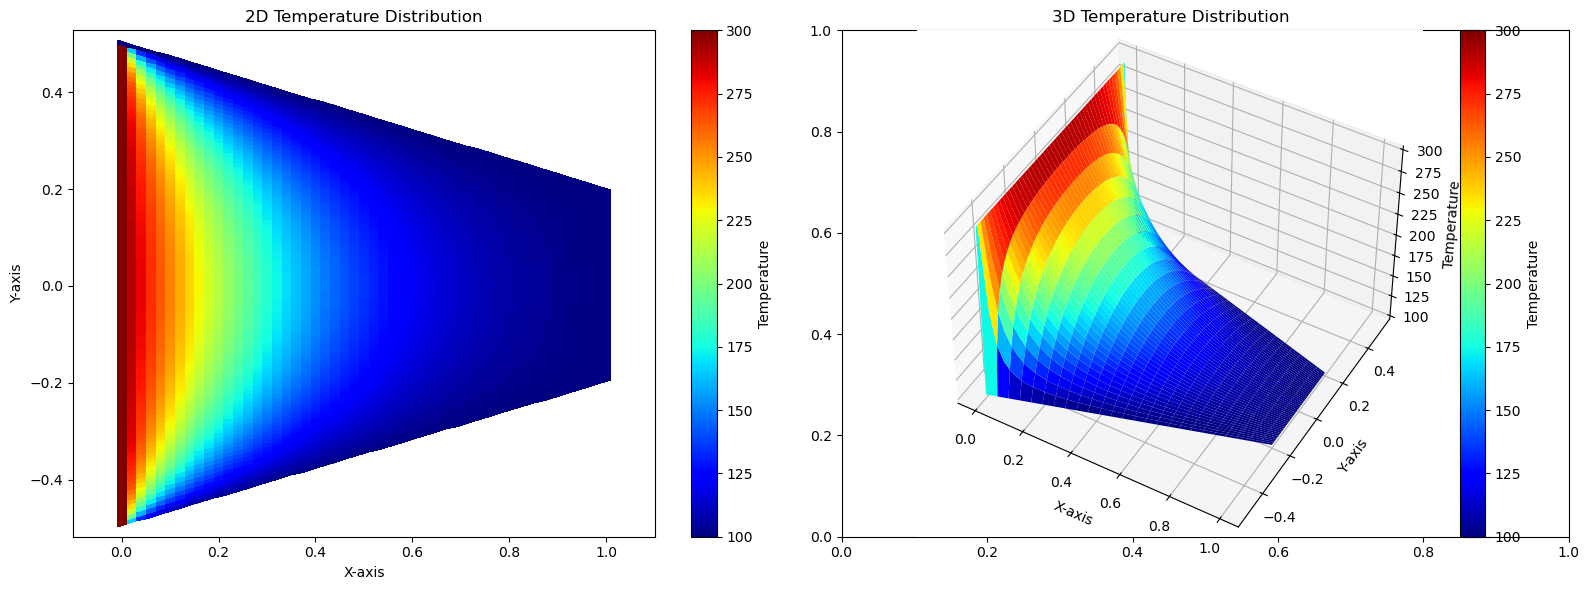

In [160]:
# if you fail to implement linear, go with rectangular case!
shape =  'linear'    # 'rectangular', 'linear',  'quadratic', 'crazy'

l = 1
dimX = 51
dimY = 51

boundary =   ['D', 'N', 'D', 'D'] # [N,S,W,E] : D : Dirichlet, N : Neumann, R : Robin
TD =  [100 , 100 , 300 , 100] # [N,S,W,E]
alpha = 20
Tinf = 90
q = 0

X, Y = setUpMesh(dimX, dimY, l, formfunction, shape)
heat = SteadyHeat2D_FVM(X, Y, boundary, TD, q, alpha, Tinf)
T = heat.solve()
heat.plot_Result(T, "both")

Assembling linear system...


C:\Users\khali\AppData\Local\Temp\ipykernel_25216\3229050716.py:876: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  self.B[idx] = b_val


Matrix size: (2601, 2601), Non-zero elements: 22550
Solving linear system...
Solution completed successfully.


C:\Users\khali\AppData\Local\Temp\ipykernel_25216\3229050716.py:910: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = plt.pcolormesh(X_combined, Y_combined, T_combined,


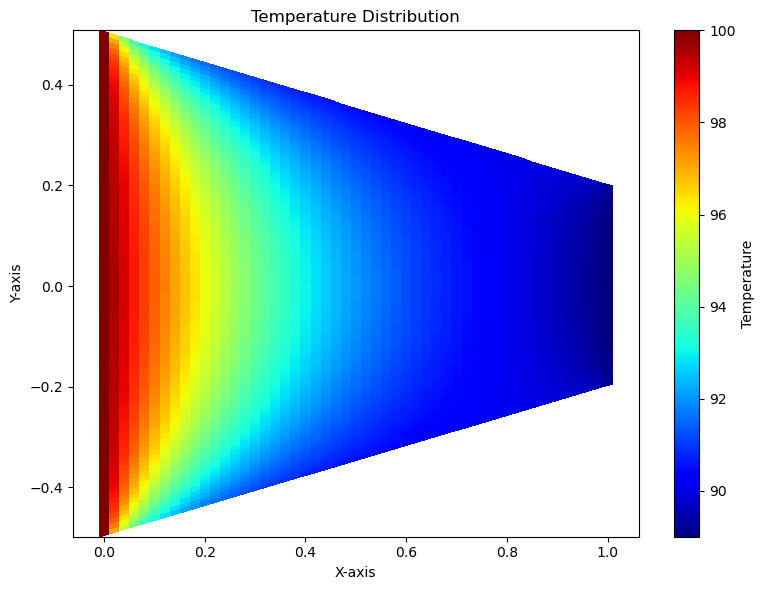

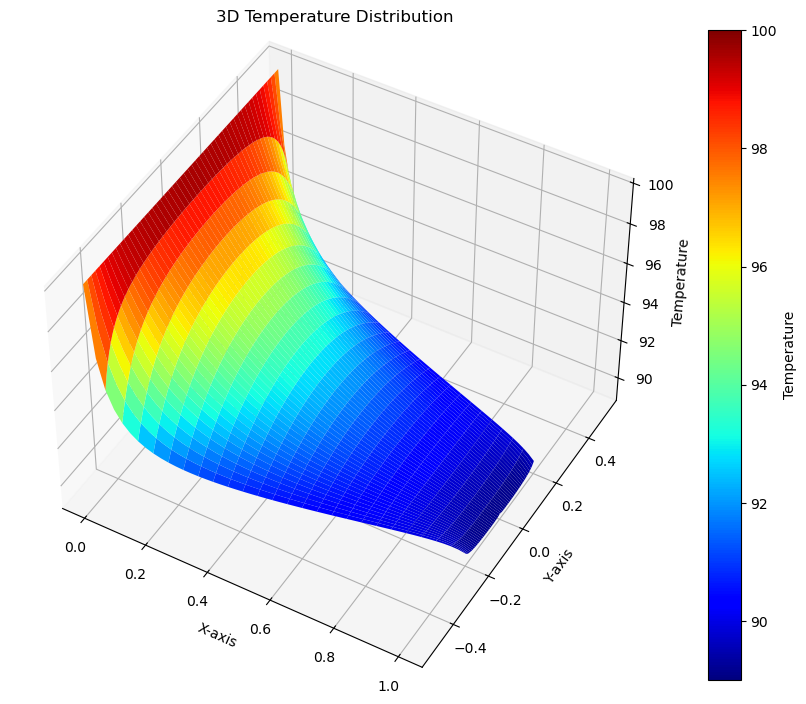

In [161]:
# if you fail to implement linear, go with rectangular case!
shape =  'linear'    # 'rectangular', 'linear',  'quadratic', 'crazy'

l = 1
dimX = 51
dimY = 51

boundary =   ['R', 'N', 'D', 'R'] # [N,S,W,E] : D : Dirichlet, N : Neumann, R : Robin
TD =  [100 , 100 , 100 , 100] # [N,S,W,E]
alpha = 20
Tinf = 90
q = 0

X, Y = setUpMesh(dimX, dimY, l, formfunction, shape)
heat = SteadyHeat2D_FVM(X, Y, boundary, TD, q, alpha, Tinf)
T = heat.solve()
heat.plot_Result(T, "2D")
heat.plot_Result(T, "3D")

Assembling linear system...


C:\Users\khali\AppData\Local\Temp\ipykernel_25216\3229050716.py:876: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  self.B[idx] = b_val


Matrix size: (4131, 4131), Non-zero elements: 36140
Solving linear system...
Solution completed successfully.


C:\Users\khali\AppData\Local\Temp\ipykernel_25216\3229050716.py:910: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = plt.pcolormesh(X_combined, Y_combined, T_combined,


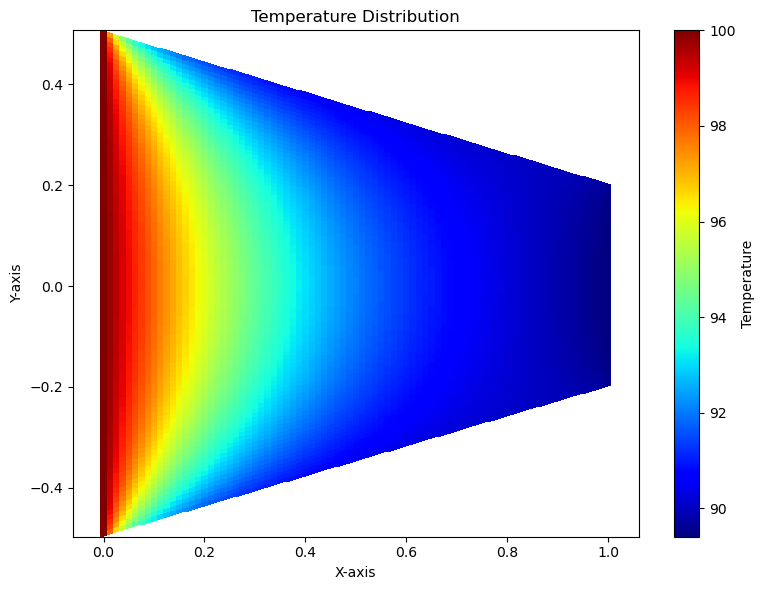

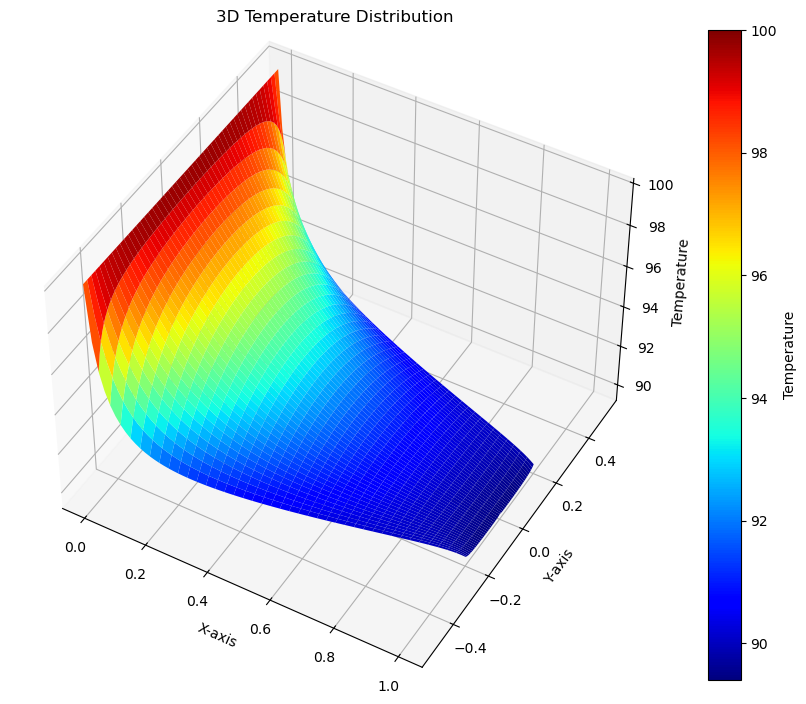

In [162]:
# if you fail to implement linear, go with rectangular case!
shape =  'linear'    # 'rectangular', 'linear',  'quadratic', 'crazy'

l = 1
dimX = 81
dimY = 51

boundary =   ['R', 'N', 'D', 'R'] # [N,S,W,E] : D : Dirichlet, N : Neumann, R : Robin
TD =  [100 , 100 , 100 , 100] # [N,S,W,E]
alpha = 20
Tinf = 90
q = 0

X, Y = setUpMesh(dimX, dimY, l, formfunction, shape)
heat = SteadyHeat2D_FVM(X, Y, boundary, TD, q, alpha, Tinf)
T = heat.solve()
heat.plot_Result(T, "2D")
heat.plot_Result(T, "3D")